Subject: s3 | Exercise: e1 | Unit: u2
Total timesteps: 3997
Global threshold range: 0.035 – 1.839
Detected: 33 reps (expected ~30)
Durations — min: 41, max: 182, mean: 82.8


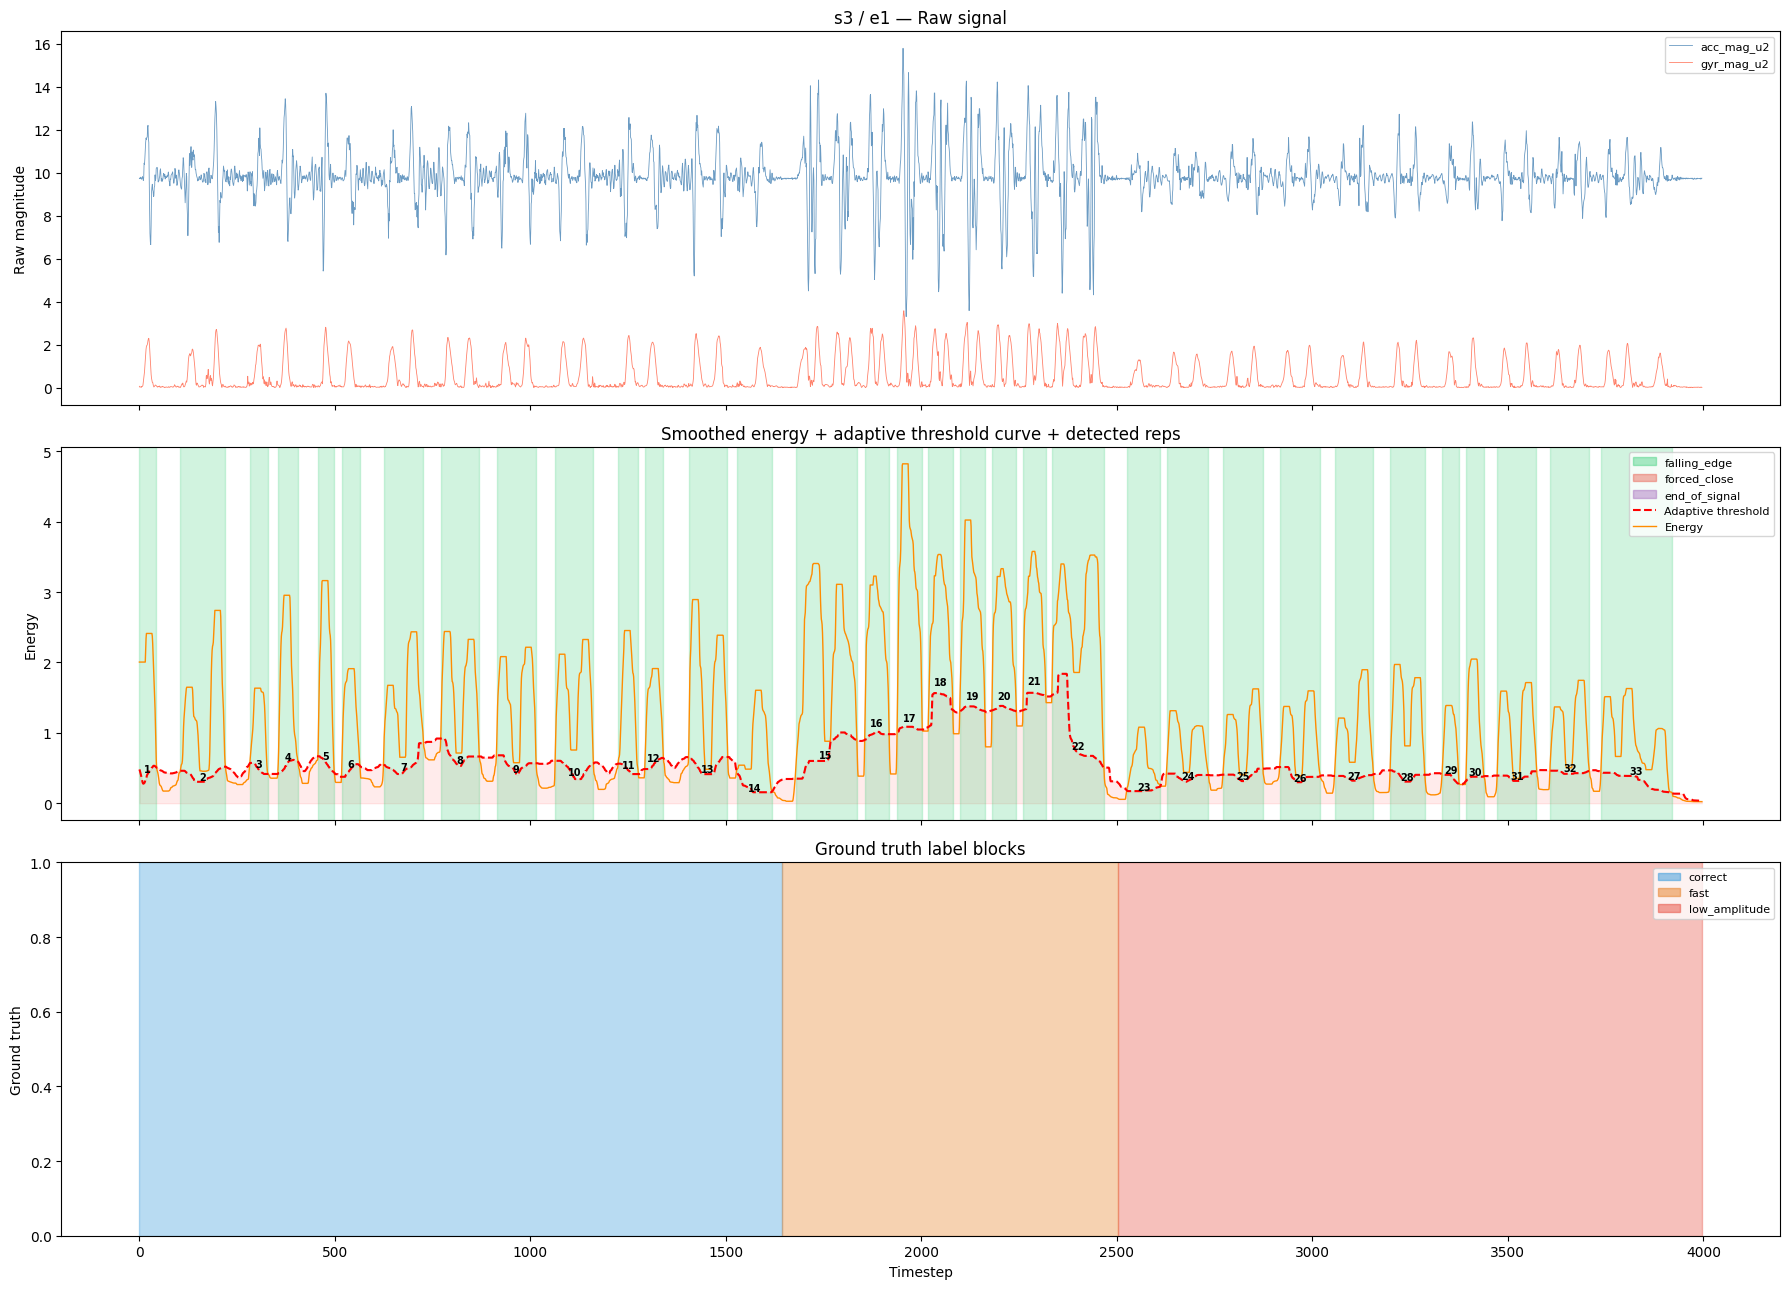

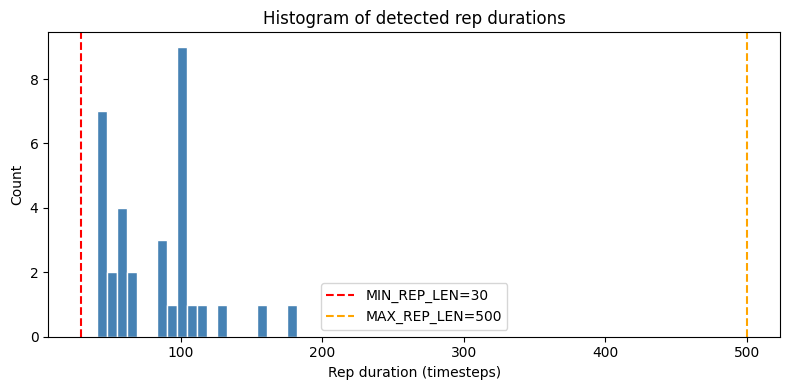

Detected rep table:
 rep  start  end  duration close_reason
   1      0   43        43 falling_edge
   2    105  219       114 falling_edge
   3    283  329        46 falling_edge
   4    354  405        51 falling_edge
   5    457  498        41 falling_edge
   6    517  563        46 falling_edge
   7    625  726       101 falling_edge
   8    771  869        98 falling_edge
   9    914 1014       100 falling_edge
  10   1064 1160        96 falling_edge
  11   1225 1276        51 falling_edge
  12   1293 1340        47 falling_edge
  13   1405 1504        99 falling_edge
  14   1528 1617        89 falling_edge
  15   1678 1834       156 falling_edge
  16   1855 1917        62 falling_edge
  17   1938 2002        64 falling_edge
  18   2018 2080        62 falling_edge
  19   2098 2162        64 falling_edge
  20   2181 2242        61 falling_edge
  21   2260 2318        58 falling_edge
  22   2334 2466       132 falling_edge
  23   2526 2611        85 falling_edge
  24   2627 2734    

In [ ]:
# ================================================================
# DIAGNOSTIC v2: Local adaptive threshold + ENERGY_WINDOW=25
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

EXERCISE = "e1"
SUBJECT  = "s3"
DATA_PATH = Path().resolve().parent / "data" / "processed_data.csv"

# ── Same constants as updated app.py ────────────────────────────
ENERGY_WINDOW  =50    # reduced from 50
SMOOTH_WINDOW  = 30
LOCAL_WINDOW   = 200   # rolling window for adaptive threshold
MIN_REP_LEN    = 30
MAX_REP_LEN    = 500
MIN_IDLE_LEN   = 10

df_full = pd.read_csv(DATA_PATH)
df = df_full[
    (df_full["subject"] == SUBJECT) &
    (df_full["exercise"] == EXERCISE)
].reset_index(drop=True)

unit = df["most_active_unit"].iloc[0]
print(f"Subject: {SUBJECT} | Exercise: {EXERCISE} | Unit: {unit}")
print(f"Total timesteps: {len(df)}")

# ── Energy ───────────────────────────────────────────────────────
acc_s = pd.Series(df[f"acc_mag_{unit}"].values)
gyr_s = pd.Series(df[f"gyr_mag_{unit}"].values)

energy = (
    acc_s.rolling(ENERGY_WINDOW, center=True).std() +
    gyr_s.rolling(ENERGY_WINDOW, center=True).std()
).bfill().ffill()
energy_smooth = energy.rolling(SMOOTH_WINDOW, center=True).median().bfill().ffill()
energy_vals   = energy_smooth.values

# ── Local adaptive threshold (Series) ───────────────────────────
local_low  = energy_smooth.rolling(LOCAL_WINDOW, center=True, min_periods=1).quantile(0.05).bfill().ffill()
local_high = energy_smooth.rolling(LOCAL_WINDOW, center=True, min_periods=1).quantile(0.60).bfill().ffill()
threshold_s    = local_low + 0.25 * (local_high - local_low)
threshold_vals = threshold_s.values

print(f"Global threshold range: {threshold_vals.min():.3f} – {threshold_vals.max():.3f}")

# ── State machine ────────────────────────────────────────────────
state        = "IDLE"
buffer_start = None
idle_streak  = 0
repetitions  = []

for t, e in enumerate(energy_vals):
    thr = threshold_vals[t]

    if state == "IDLE":
        if e >= thr:
            state        = "ACTIVE"
            buffer_start = t
            idle_streak  = 0
    else:
        rep_len = t - buffer_start
        if e < thr:
            idle_streak += 1
        else:
            idle_streak = 0

        falling_edge = (idle_streak >= MIN_IDLE_LEN)
        forced_close = (rep_len >= MAX_REP_LEN)

        if falling_edge or forced_close:
            close_at = t - idle_streak if falling_edge else t
            reason   = "falling_edge" if falling_edge else "forced_close"
            if (close_at - buffer_start) >= MIN_REP_LEN:
                repetitions.append((buffer_start, close_at, reason))
            state        = "IDLE"
            buffer_start = None
            idle_streak  = 0

if state == "ACTIVE" and buffer_start is not None:
    if (len(df) - buffer_start) >= MIN_REP_LEN:
        repetitions.append((buffer_start, len(df), "end_of_signal"))

durations = [e - s for s, e, _ in repetitions]
print(f"Detected: {len(repetitions)} reps (expected ~30)")
if durations:
    print(f"Durations — min: {min(durations)}, max: {max(durations)}, mean: {np.mean(durations):.1f}")

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

# Panel 1: raw signal
axes[0].plot(acc_s.values, color="steelblue", lw=0.6, alpha=0.8, label=f"acc_mag_{unit}")
axes[0].plot(gyr_s.values, color="tomato",    lw=0.6, alpha=0.8, label=f"gyr_mag_{unit}")
axes[0].set_ylabel("Raw magnitude")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title(f"{SUBJECT} / {EXERCISE} — Raw signal")

# Panel 2: energy + adaptive threshold curve + detected reps
axes[1].plot(energy_vals,    color="darkorange", lw=1.0,  label="Smoothed energy")
axes[1].plot(threshold_vals, color="red",        lw=1.5,
             linestyle="--", label="Adaptive threshold (local)")
axes[1].fill_between(range(len(threshold_vals)), threshold_vals,
                     alpha=0.08, color="red")   # shade below threshold for clarity

colours = {"falling_edge": "#2ecc71", "forced_close": "#e74c3c", "end_of_signal": "#9b59b6"}
for i, (start, end, reason) in enumerate(repetitions):
    axes[1].axvspan(start, end, alpha=0.22, color=colours.get(reason, "grey"))
    axes[1].text(
        (start + end) / 2,
        threshold_vals[int((start + end) / 2)] * 1.08,
        str(i + 1), fontsize=7, ha="center", color="black", fontweight="bold"
    )

axes[1].set_ylabel("Energy")
axes[1].set_title("Smoothed energy + adaptive threshold curve + detected reps")
patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in colours.items()]
axes[1].legend(handles=patches + [
    plt.Line2D([0], [0], color="red",        lw=1.5, linestyle="--", label="Adaptive threshold"),
    plt.Line2D([0], [0], color="darkorange", lw=1.0, label="Energy"),
], loc="upper right", fontsize=8)

# Panel 3: ground truth
label_colours = {"correct": "#3498db", "fast": "#e67e22", "low_amplitude": "#e74c3c"}
prev_label, block_start = df["label"].iloc[0], 0
seen_labels = set()
for t in range(1, len(df)):
    curr = df["label"].iloc[t]
    if curr != prev_label or t == len(df) - 1:
        axes[2].axvspan(block_start, t, alpha=0.35,
                        color=label_colours.get(prev_label, "grey"))
        seen_labels.add(prev_label)
        block_start = t
        prev_label  = curr

axes[2].set_ylabel("Ground truth")
axes[2].set_xlabel("Timestep")
axes[2].set_title("Ground truth label blocks")
handles = [mpatches.Patch(color=label_colours[l], alpha=0.5, label=l)
           for l in label_colours if l in seen_labels]
axes[2].legend(handles=handles, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# ── Duration histogram ───────────────────────────────────────────
if durations:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.hist(durations, bins=20, color="steelblue", edgecolor="white")
    ax2.axvline(MIN_REP_LEN, color="red",    linestyle="--", label=f"MIN_REP_LEN={MIN_REP_LEN}")
    ax2.axvline(MAX_REP_LEN, color="orange", linestyle="--", label=f"MAX_REP_LEN={MAX_REP_LEN}")
    ax2.set_xlabel("Rep duration (timesteps)")
    ax2.set_ylabel("Count")
    ax2.set_title("Histogram of detected rep durations")
    ax2.legend()
    plt.tight_layout()
    plt.show()

# ── Rep table ────────────────────────────────────────────────────
rep_table = pd.DataFrame([
    {"rep": i+1, "start": s, "end": e, "duration": e-s, "close_reason": r}
    for i, (s, e, r) in enumerate(repetitions)
])
print("Detected rep table:")
print(rep_table.to_string(index=False))